In [1]:
from torch.multiprocessing import Pool, set_start_method
set_start_method('spawn', force=True)
import torch
from torch.multiprocessing import Pool
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch import fit_fully_bayesian_model_nuts
from botorch.models.fully_bayesian import SaasFullyBayesianSingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import (
    qLogExpectedImprovement,
    qLogNoisyExpectedImprovement,
)
from gpytorch.kernels import MaternKernel,ScaleKernel,RBFKernel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from botorch.sampling.normal import SobolQMCNormalSampler
import os
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import r2_score 
os.environ["MKL_THREADING_LAYER"] = "GNU"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
from utility import parallel_optimize_acqf

cpu


## Load data

In [4]:
address = "./data/BO_SAM_Additive.xlsx"
df = pd.read_excel(address,sheet_name='init')

In [5]:
df

,Unnamed: 0,DMF,NFM,EA,Me-4,Py3,4PADCB,4F-BASZ,F3EABr,5F-SPBS,Voc*FF,Voc,FF,Jsc,PCE
0,1-2,0.81,0.17,0.02,0.3,0.3,0.15,0.9,0.2,0.4,85.646117,1.113851,76.891922,2.024774e+01,1.734141e+01
1,1-3,0.81,0.17,0.02,0.2,0.2,0.30,0.2,1.4,0.2,88.706298,1.122255,79.042874,2.407515e+01,2.135618e+01
2,1-4,0.81,0.17,0.02,0.8,0.4,0.90,0.5,0.4,0.2,83.084524,1.141847,72.763255,2.413926e+01,2.005599e+01
3,1-5,0.81,0.17,0.02,0.1,0.3,0.60,0.8,1.4,0.2,78.470861,1.104622,71.038624,2.109343e+01,1.655220e+01
4,1-6,0.81,0.17,0.02,0.6,0.4,0.45,0.5,0.6,0.0,83.720730,1.137151,73.623215,2.176998e+01,1.822598e+01
5,1-7,0.81,0.17,0.02,1.0,0.9,0.00,0.0,0.2,2.0,78.933213,1.113397,70.894023,2.392239e+01,1.888271e+01
6,1-8,0.81,0.17,0.02,0.0,1.0,0.00,0.2,1.4,0.6,80.945737,1.104621,73.279191,2.256793e+01,1.826777e+01
7,2-1,0.81,0.17,0.02,0.2,0.4,1.50,0.3,0.4,1.6,88.260779,1.139122,77.481437,2.403833e+01,2.121642e+01
8,2-2,0.81,0.17,0.02,0.1,0.4,0.45,0.0,1.2,0.0,91.016724,1.131474,80.440812,2.378053e+01,2.164426e+01
9,2-3,0.81,0.17,0.02,0.4,0.5,0.30,0.0,0.8,1.2,88.879403,1.136148,78.228696,2.336178e+01,2.076381e+01


In [6]:
dtype = torch.double 

data = df.iloc[:,[4,5,6,7,8,9,10]]

train_X =data.iloc[:,:-1].values
train_Y = data.iloc[:,-1].values

train_X_tensor = torch.tensor(train_X,device=device, dtype=dtype)
train_Y_tensor = torch.tensor(train_Y,device=device, dtype=dtype).reshape(-1,1)

# BO

In [7]:
bounds = torch.tensor([
        [ 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],   # 下界
    [ 0.6, 0.7, 1.5, 0.5, 1.2, 1.5]  # 上界
], dtype=torch.double, device=device)


params = {
    "BATCH_SIZE": 62, # 候选点数量
    "NUM_RESTARTS" : 10, # 优化起始点top-k
    "RAW_SAMPLES" : 512, # 优化起始点
    "NOISE_SE" : 2, # 噪声标准差
    "MC_SAMPLES" : 512, # 用于评估高维分布均值的样本量
    "bounds" : bounds
}

def Bayesian_Optimization(params,train_X_tensor,train_Y_tensor):

    train_yvar = torch.tensor(params['NOISE_SE']**2, device=device, dtype=dtype)
    
    gp = SingleTaskGP(
      train_X=train_X_tensor,
      train_Y=train_Y_tensor,
      train_Yvar = train_yvar.expand_as(train_Y_tensor),
      covar_module = ScaleKernel(MaternKernel(nu=1.5,ard_num_dims = train_X_tensor.shape[-1])),
      input_transform=Normalize(d=train_X_tensor.shape[-1]),
      outcome_transform=Standardize(m=train_Y_tensor.shape[-1])
    ).to(device)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll, options={"maxiter":40})
    
    # define the qEI and qNEI acquisition modules using a QMC sampler
    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([params['MC_SAMPLES']]))
    
    # for best_f, we use the best observed noisy values as an approximation
    # qLogEI = qLogExpectedImprovement(
    #     model=gp,
    #     best_f=train_Y_tensor.max(),
    #     sampler=qmc_sampler,
    # ).to(device)
    
    qLogNEI = qLogNoisyExpectedImprovement(
        model=gp,
        X_baseline=train_X_tensor,
        sampler=qmc_sampler
    ).to(device)
    # 定义等式约束

    # optimize
    candidates, acq_value = parallel_optimize_acqf(
        num_processes = 36,
        acq_function=qLogNEI,
        bounds=params['bounds'],
        q=params['BATCH_SIZE'],
        num_restarts=params['NUM_RESTARTS'],
        raw_samples=params['RAW_SAMPLES'],
        options={"batch_limit": 8, "maxiter": 200},
        equality_constraints = None,
        # inequality_constraints=None,
        inequality_constraints=[  # 添加不等式约束
            (
                torch.tensor([0, 1, 2], device=device, dtype=torch.long),  # 约束涉及的维度索引
                torch.tensor([-1.0, -1.0, -1.0], device=device, dtype=dtype),  # 线性系数
                torch.tensor(-1.6, dtype=dtype, device=device)  # 上界
            ),
            (
                torch.tensor([3, 4, 5], device=device, dtype=torch.long),  # 约束涉及的维度索引
                torch.tensor([-1.0, -1.0, -1.0], device=device, dtype=dtype),  # 线性系数
                torch.tensor(-2.5, dtype=dtype, device=device)  # 上界
            )
        ],
        device=device
    )
    # observe new values
    new_x = candidates.cpu().detach()
    

    return gp, new_x,acq_value.cpu().detach()

In [ ]:
%%time
train_num = int(len(data)*1.0)
model,new_x,acq_value = Bayesian_Optimization(params,train_X_tensor[:train_num,:],train_Y_tensor[:train_num,:])

In [11]:
acq_value

tensor(1.3344, dtype=torch.float64)

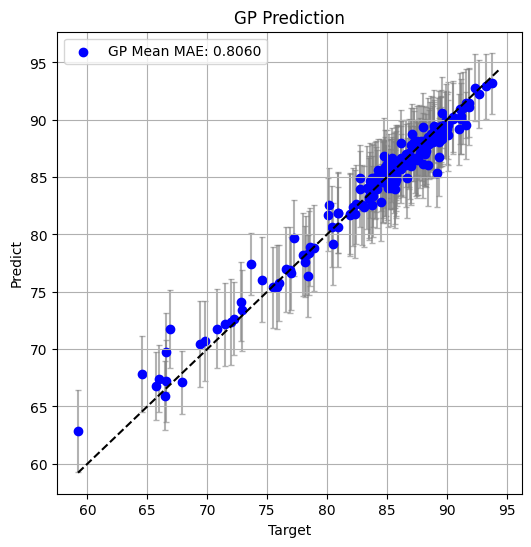

In [12]:
index = train_num
# 获取后验预测
with torch.no_grad():
    posterior = model.posterior(train_X_tensor[:,:])
    mean = posterior.mean.cpu().numpy()  # [100, 1]
    variance = posterior.variance.cpu().numpy()  # [100, 1]
    std = np.sqrt(variance)  # 标准差

# 可视化
plt.figure(figsize=(6, 6))
train_Y_np = train_Y_tensor.cpu().numpy().squeeze()[:]
mean = mean.squeeze()  # [100]
std = std.squeeze()    # [100]

# 计算 MAE
mae = np.mean(np.abs(train_Y_np - mean))

# 绘制均值和置信区间
plt.scatter(train_Y_np, mean, c='b', label=f'GP Mean MAE: {mae:.4f}')
plt.errorbar(train_Y_np, mean, yerr=2*std, ms=0, 
             ls='', capsize=2, alpha=0.6,
             color='gray', zorder=0)

plot_range = [np.min([train_Y_np, mean-std]), np.max([train_Y_np, mean+std])]
plt.plot(plot_range, plot_range, 'k--')  # 黑色虚线

plt.xlabel('Target')
plt.ylabel('Predict')
plt.title('GP Prediction') 

plt.legend()
plt.grid(True)
plt.show()

In [13]:
posterior = model.posterior(new_x[0].to(device))
pred = posterior.mean.cpu().detach().numpy()
var = posterior.variance.cpu().detach().numpy()
std = np.sqrt(var)

# 对 new_x 的前三列保留两位小数，其余列保留一位小数
new_x_np = new_x.cpu().detach().numpy()[0]
new_x_formatted = np.zeros_like(new_x_np)
new_x_formatted[:,:3] = np.round(new_x_np[:,:3], 1)  # 前三列保留两位小数
new_x_formatted[:,3:] = np.round(new_x_np[:,3:], 1)  # 其余列保留一位小数

data_with_target = np.concatenate([new_x_formatted,pred,std],axis=1)
recommend = pd.DataFrame(data_with_target,columns=list(data.columns[:-1])+['pred_'+data.columns[-1]+'mean','pred_'+data.columns[-1]+'std'])
# 假设你的DataFrame叫df
recommend.index = [str(i) for i in range(1, len(recommend) + 1)]
recommend_sorted = recommend.sort_values(by='pred_Voc*FFmean', ascending=False)

In [16]:
recommend_sorted

,Me-4,Py3,4PADCB,4F-BASZ,F3EABr,5F-SPBS,pred_Voc*FFmean,pred_Voc*FFstd
17,0.3,0.2,0.2,0.1,0.3,0.0,93.925408,2.054959
30,0.3,0.2,0.3,0.1,0.6,0.0,93.890415,2.508152
35,0.3,0.1,0.3,0.2,0.3,0.0,93.806996,2.480533
22,0.2,0.3,0.5,0.1,0.4,0.0,93.723428,2.414128
34,0.2,0.2,0.3,0.1,0.0,0.4,93.660121,1.784077
...,...,...,...,...,...,...,...,...
20,0.3,0.0,0.7,0.5,1.1,0.9,85.955342,2.856407
58,0.0,0.4,0.6,0.0,1.2,0.6,85.754794,2.340950
60,0.3,0.0,1.2,0.2,1.2,0.6,85.717502,2.648380
53,0.1,0.2,1.3,0.1,0.1,0.1,84.483754,2.473768


In [22]:
# 将两个 DataFrame 保存到同一个 Excel 文件的不同 Sheet 中
with pd.ExcelWriter(address, mode='a', engine='openpyxl', if_sheet_exists='overlay') as writer:
    recommend.to_excel(writer, sheet_name='round1', startcol=0)